# TinyLLM Sentiment Analysis - High Accuracy Model

## Improvements from v1:
- Larger model architecture (384d, 6 layers, 8 heads)
- Full IMDB dataset (25K train, 25K test)
- Increased max_length to 256
- Advanced training techniques
- Better tokenizer with 15K vocabulary

In [18]:
# Install required packages
!pip install torch torchvision --quiet
!pip install numpy pandas scikit-learn --quiet
!pip install matplotlib seaborn tqdm --quiet
print("✓ Packages installed successfully!")


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
✓ Packages installed successfully!


In [19]:
# Imports

import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
import math
import re
import random
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [20]:
# Set random seeds for reproducibility

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Check GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print()
print(f'🚀 Using device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB')


🚀 Using device: cpu


## Improved Tokenizer

In [21]:
class AdvancedTokenizer:
    """Advanced tokenizer with BPE-style subword handling and special tokens"""

    def __init__(self, vocab_size=15000):
        self.vocab_size = vocab_size
        self.word2idx = {}
        self.idx2word = {}
        self.special_tokens = ['<PAD>', '<UNK>', '<CLS>', '<SEP>', '<EOS>']

    def _normalize(self, text):
        """Normalize text: lowercase, clean URLs, remove special chars"""
        text = text.lower().strip()
        # Remove URLs
        text = re.sub(r"https?://\S+|www\.\S+", " ", text)
        # Keep apostrophes for contractions
        text = re.sub(r"[^a-z0-9'!?.,\s-]", " ", text)
        # Normalize whitespace
        text = re.sub(r"\s+", " ", text).strip()
        return text

    def _tokenize(self, text):
        """Basic tokenization with subword handling"""
        text = self._normalize(text)
        # Split on whitespace first
        tokens = text.split()
        # Handle common contractions and punctuation
        result = []
        for token in tokens:
            if token in ['!', '?', ',', '.', "'"]:
                if result and result[-1] not in ['<CLS>', '<SEP>', '<EOS>']:
                    result[-1] = result[-1] + token
                else:
                    result.append(token)
            else:
                result.append(token)
        return [t for t in result if t]

    def build_vocab(self, texts):
        """Build vocabulary from training texts with frequency filtering"""
        word_counts = Counter()
        for text in texts:
            tokens = self._tokenize(text)
            word_counts.update(tokens)

        # Add special tokens first
        vocab = self.special_tokens.copy()
        
        # Add words by frequency, up to vocab_size
        remaining = self.vocab_size - len(self.special_tokens)
        vocab += [word for word, _ in word_counts.most_common(remaining)]

        self.word2idx = {word: idx for idx, word in enumerate(vocab)}
        self.idx2word = {idx: word for word, idx in self.word2idx.items()}

        print(f"✓ Vocabulary built: {len(self.word2idx)} tokens")
        print(f"  Special tokens: {len(self.special_tokens)}")
        print(f"  Vocabulary words: {len(self.word2idx) - len(self.special_tokens)}")

    def encode(self, text, max_length=256, return_mask=False):
        """Convert text to token indices with BERT-style [CLS] [SEP] format"""
        tokens = self._tokenize(text)
        
        # Add special tokens: [CLS] ... tokens ... [EOS]
        indexed = ['<CLS>'] + tokens + ['<EOS>']
        indices = [self.word2idx.get(token, self.word2idx['<UNK>']) for token in indexed]

        # Truncate if needed
        if len(indices) > max_length:
            indices = indices[:max_length]
            indices[-1] = self.word2idx['<EOS>']

        # Create attention mask
        attention_mask = [1] * len(indices)

        # Pad if needed
        if len(indices) < max_length:
            pad_len = max_length - len(indices)
            indices += [self.word2idx['<PAD>']] * pad_len
            attention_mask += [0] * pad_len

        if return_mask:
            return indices, attention_mask
        return indices

    def decode(self, indices):
        """Convert token indices back to text"""
        blocked = {'<PAD>', '<CLS>', '<SEP>', '<EOS>'}
        words = [self.idx2word.get(idx, '<UNK>') for idx in indices]
        words = [w for w in words if w not in blocked]
        return ' '.join(words)


# Test tokenizer
print("Testing advanced tokenizer...")
test_tokenizer = AdvancedTokenizer(vocab_size=1000)
test_tokenizer.build_vocab(["Hello world! This is a test.", "Another example text."])
encoded, mask = test_tokenizer.encode("This is an amazing movie!", max_length=20, return_mask=True)
print(f"Encoded: {encoded[:15]}")
print(f"Mask:    {mask[:15]}")
decoded = test_tokenizer.decode(encoded)
print(f"Decoded: {decoded}")
print("✓ Advanced tokenizer working!")

Testing advanced tokenizer...
✓ Vocabulary built: 14 tokens
  Special tokens: 5
  Vocabulary words: 9
Encoded: [2, 7, 8, 1, 1, 1, 4, 0, 0, 0, 0, 0, 0, 0, 0]
Mask:    [1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0]
Decoded: this is <UNK> <UNK> <UNK>
✓ Advanced tokenizer working!


## Positional Encoding

In [22]:
class PositionalEncoding(nn.Module):
    """Sinusoidal positional encoding with learnable extensions"""
    
    def __init__(self, d_model, max_len=512, learnable=False):
        super().__init__()
        
        # Fixed sinusoidal positional encoding
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * 
                            (-math.log(10000.0) / d_model))
        
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        
        self.register_buffer('pe', pe.unsqueeze(0))
        
        # Optional learnable positional encoding
        if learnable:
            self.learnable_pe = nn.Parameter(torch.randn(1, max_len, d_model) * 0.02)
        else:
            self.learnable_pe = None
        
    def forward(self, x):
        # x: [batch_size, seq_len, d_model]
        x = x + self.pe[:, :x.size(1), :]
        if self.learnable_pe is not None:
            x = x + self.learnable_pe[:, :x.size(1), :]
        return x


# Test positional encoding
print("Testing positional encoding...")
pos_enc = PositionalEncoding(d_model=128, max_len=256)
test_input = torch.randn(2, 50, 128)
output = pos_enc(test_input)
print(f"Input shape: {test_input.shape}")
print(f"Output shape: {output.shape}")
print("✓ Positional encoding working!")

Testing positional encoding...
Input shape: torch.Size([2, 50, 128])
Output shape: torch.Size([2, 50, 128])
✓ Positional encoding working!


## Multi-Head Attention with Dropout

In [23]:
class MultiHeadAttention(nn.Module):
    """Multi-head self-attention with improved dropout and activation"""

    def __init__(self, d_model, num_heads, dropout=0.1):
        super().__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"

        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads
        self.scale = math.sqrt(self.d_k)

        # Linear projections with dropout
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)
        
        self.attn_dropout = nn.Dropout(dropout)
        self.output_dropout = nn.Dropout(dropout)

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        """Compute scaled dot-product attention with optional masking"""
        # Q, K, V: [batch, heads, seq_len, d_k]
        scores = torch.matmul(Q, K.transpose(-2, -1)) / self.scale

        if mask is not None:
            # Expand mask: [batch, 1, 1, seq_len] -> [batch, heads, seq_len, seq_len]
            mask = mask.unsqueeze(1).unsqueeze(2)
            scores = scores.masked_fill(~mask, torch.finfo(scores.dtype).min)

        attention_weights = torch.softmax(scores, dim=-1)
        attention_weights = self.attn_dropout(attention_weights)
        
        output = torch.matmul(attention_weights, V)
        
        return output, attention_weights

    def forward(self, x, mask=None):
        batch_size = x.size(0)
        seq_len = x.size(1)

        # Linear projections and reshape to heads
        Q = self.W_q(x).view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)
        K = self.W_k(x).view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)
        V = self.W_v(x).view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)

        # Compute attention
        attn_output, attn_weights = self.scaled_dot_product_attention(Q, K, V, mask)

        # Reshape back: [batch, heads, seq_len, d_k] -> [batch, seq_len, d_model]
        attn_output = attn_output.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)
        
        # Final output projection
        output = self.output_dropout(self.W_o(attn_output))

        return output, attn_weights


# Test attention
print("Testing multi-head attention...")
mha = MultiHeadAttention(d_model=128, num_heads=8)
test_input = torch.randn(2, 30, 128)
test_mask = torch.ones(2, 30, dtype=torch.bool)
output, weights = mha(test_input, test_mask)
print(f"Input shape: {test_input.shape}")
print(f"Output shape: {output.shape}")
print(f"Attention weights shape: {weights.shape}")
print("✓ Multi-head attention working!")

Testing multi-head attention...
Input shape: torch.Size([2, 30, 128])
Output shape: torch.Size([2, 30, 128])
Attention weights shape: torch.Size([2, 8, 30, 30])
✓ Multi-head attention working!


## Feed-Forward Network

In [24]:
class FeedForward(nn.Module):
    """Position-wise feed-forward network with GELU activation"""
    
    def __init__(self, d_model, d_ff, dropout=0.1, activation='gelu'):
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.linear2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)
        
        if activation == 'gelu':
            self.activation = nn.GELU()
        else:
            self.activation = nn.ReLU()
        
    def forward(self, x):
        return self.linear2(self.dropout(self.activation(self.linear1(x))))


# Test feed-forward
print("Testing feed-forward network...")
ff = FeedForward(d_model=128, d_ff=512)
test_input = torch.randn(2, 30, 128)
output = ff(test_input)
print(f"Input shape: {test_input.shape}")
print(f"Output shape: {output.shape}")
print("✓ Feed-forward network working!")

Testing feed-forward network...
Input shape: torch.Size([2, 30, 128])
Output shape: torch.Size([2, 30, 128])
✓ Feed-forward network working!


## Transformer Block

In [25]:
class TransformerBlock(nn.Module):
    """Single transformer encoder block with pre-LN configuration"""
    
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1, use_pre_ln=False):
        super().__init__()
        
        self.use_pre_ln = use_pre_ln
        
        self.attention = MultiHeadAttention(d_model, num_heads, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        
        self.ff = FeedForward(d_model, d_ff, dropout)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x, mask=None):
        if self.use_pre_ln:
            # Pre-LN configuration (more stable for deep networks)
            attn_input = self.norm1(x)
            attn_output, attn_weights = self.attention(attn_input, mask)
            x = x + self.dropout(attn_output)
            
            ff_input = self.norm2(x)
            ff_output = self.ff(ff_input)
            x = x + self.dropout(ff_output)
        else:
            # Post-LN configuration (original)
            attn_output, attn_weights = self.attention(x, mask)
            x = self.norm1(x + self.dropout(attn_output))
            
            ff_output = self.ff(x)
            x = self.norm2(x + self.dropout(ff_output))
        
        return x, attn_weights


# Test transformer block
print("Testing transformer block...")
block = TransformerBlock(d_model=128, num_heads=8, d_ff=512, use_pre_ln=True)
test_input = torch.randn(2, 30, 128)
output, weights = block(test_input)
print(f"Input shape: {test_input.shape}")
print(f"Output shape: {output.shape}")
print("✓ Transformer block working!")

Testing transformer block...
Input shape: torch.Size([2, 30, 128])
Output shape: torch.Size([2, 30, 128])
✓ Transformer block working!


## Enhanced TinyLLM Model

In [26]:
class TinyLLM(nn.Module):
    """Enhanced TinyLLM for high-accuracy sentiment classification"""

    def __init__(self, vocab_size, d_model=384, num_heads=8,
                 num_layers=6, d_ff=1536, max_len=256,
                 num_classes=2, dropout=0.15, pad_idx=0, use_pre_ln=True):
        super().__init__()

        self.d_model = d_model
        self.pad_idx = pad_idx
        self.use_pre_ln = use_pre_ln

        # Token and segment embeddings
        self.token_embedding = nn.Embedding(vocab_size, d_model, padding_idx=pad_idx)
        self.embedding_dropout = nn.Dropout(dropout)
        
        # Positional encoding
        self.pos_encoding = PositionalEncoding(d_model, max_len)

        # Stack of transformer blocks
        self.transformer_blocks = nn.ModuleList([
            TransformerBlock(d_model, num_heads, d_ff, dropout, use_pre_ln)
            for _ in range(num_layers)
        ])

        # Final layer norm
        self.final_norm = nn.LayerNorm(d_model)

        # Multi-pooling classifier
        self.classifier = nn.Sequential(
            nn.Linear(d_model * 4, d_model * 2),  # CLS + mean + max + attention pool
            nn.LayerNorm(d_model * 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 2, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, num_classes)
        )

        self._init_weights()

    def _init_weights(self):
        """Initialize weights with proper scaling"""
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)
        
        # Initialize embeddings
        nn.init.normal_(self.token_embedding.weight, mean=0.0, std=0.02)
        if self.pad_idx is not None:
            self.token_embedding.weight.data[self.pad_idx].zero_()

    def forward(self, x, attention_mask=None):
        batch_size = x.size(0)
        seq_len = x.size(1)

        if attention_mask is None:
            attention_mask = (x != self.pad_idx).long()

        # Create padding mask for attention
        padding_mask = attention_mask.bool()

        # Token embeddings with scaling
        x = self.token_embedding(x) * math.sqrt(self.d_model)
        x = self.pos_encoding(x)
        x = self.embedding_dropout(x)

        # Store attention weights
        attention_weights = []
        
        # Pass through transformer blocks
        for block in self.transformer_blocks:
            x, attn_weights = block(x, padding_mask)
            attention_weights.append(attn_weights)

        # Final layer norm
        x = self.final_norm(x)

        # Multi-pooling strategy
        # 1. CLS token
        cls_repr = x[:, 0, :]
        
        # 2. Mean pooling (masked)
        mask_expanded = attention_mask.unsqueeze(-1).float()
        sum_repr = (x * mask_expanded).sum(dim=1)
        count = mask_expanded.sum(dim=1).clamp(min=1)
        mean_repr = sum_repr / count
        
        # 3. Max pooling (masked)
        x_masked = x.clone()
        x_masked[~padding_mask] = float('-inf')
        max_repr, _ = x_masked.max(dim=1)
        
        # 4. Attention-weighted pooling
        # Use average of last layer attention weights
        last_attn = attention_weights[-1]  # [batch, heads, seq, seq]
        attn_weights_mean = last_attn.mean(dim=1)  # [batch, seq, seq]
        attn_pool = torch.bmm(attn_weights_mean, x)  # [batch, seq, d_model]
        attn_pool_repr = attn_pool[:, 0, :]  # Use CLS position
        
        # Concatenate all pooling strategies
        combined = torch.cat([cls_repr, mean_repr, max_repr, attn_pool_repr], dim=-1)

        # Classification
        logits = self.classifier(combined)

        return logits, attention_weights


print("✓ Enhanced TinyLLM model defined successfully!")

✓ Enhanced TinyLLM model defined successfully!


## Dataset Class

In [27]:
class SentimentDataset(Dataset):
    """Custom dataset for sentiment analysis with data augmentation"""

    def __init__(self, texts, labels, tokenizer, max_length=256, augment=False):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.augment = augment

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]

        # Simple data augmentation (optional)
        if self.augment and random.random() < 0.1:
            # Random capitalization
            words = text.split()

            if words and random.random() < 0.3:
                cap_idx = random.randint(0, len(words) - 1)
                words[cap_idx] = words[cap_idx].upper()
                text = ' '.join(words)

        tokens, attention_mask = self.tokenizer.encode(text, self.max_length, return_mask=True)

        return {
            'input_ids': torch.tensor(tokens, dtype=torch.long),
            'attention_mask': torch.tensor(attention_mask, dtype=torch.long),
            'labels': torch.tensor(label, dtype=torch.long)
        }


print("✓ Dataset class defined!")

✓ Dataset class defined!


## Training Function with Advanced Features

In [28]:
def train_model(model, train_loader, val_loader, epochs=15, lr=2e-4, patience=5, 
                label_smoothing=0.1, warmup_epochs=2, grad_clip=1.0):
    """Train model with warmup, cosine annealing, mixed precision, and early stopping"""

    model = model.to(device)

    # Loss function with label smoothing
    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    
    # Optimizer with weight decay
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01, betas=(0.9, 0.999))
    
    # Learning rate scheduler with warmup
    warmup_steps = warmup_epochs * len(train_loader)
    total_steps = epochs * len(train_loader)
    
    def lr_lambda(step):
        if step < warmup_steps:
            return float(step) / float(max(1, warmup_steps))
        progress = float(step - warmup_steps) / float(max(1, total_steps - warmup_steps))
        return max(0.0, 0.5 * (1.0 + math.cos(math.pi * progress)))
    
    scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

    # Mixed precision scaler
    scaler = torch.cuda.amp.GradScaler(enabled=(device.type == 'cuda'))

    # Track best metrics
    best_val_f1 = 0.0
    best_val_acc = 0.0
    early_stop_counter = 0

    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': [], 'val_f1': [], 'lr': []
    }

    for epoch in range(epochs):
        # Training phase
        model.train()
        train_loss = 0
        train_correct = 0
        train_total = 0

        train_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs} [Train]')
        for batch in train_bar:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            optimizer.zero_grad(set_to_none=True)

            # Mixed precision forward pass
            with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
                logits, _ = model(input_ids, attention_mask)
                loss = criterion(logits, labels)

            # Backward pass with gradient clipping
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()

            # Track metrics
            train_loss += loss.item()
            _, predicted = torch.max(logits, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()

            train_bar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'acc': f'{100 * train_correct / max(train_total, 1):.2f}%',
                'lr': f'{scheduler.get_last_lr()[0]:.2e}'
            })

        # Validation phase
        model.eval()
        val_loss = 0
        all_preds = []
        all_labels = []

        with torch.no_grad():
            val_bar = tqdm(val_loader, desc=f'Epoch {epoch+1}/{epochs} [Val]')
            for batch in val_bar:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)

                with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
                    logits, _ = model(input_ids, attention_mask)
                    loss = criterion(logits, labels)

                val_loss += loss.item()
                preds = torch.argmax(logits, dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

                running_acc = 100 * accuracy_score(all_labels, all_preds)
                val_bar.set_postfix({
                    'loss': f'{loss.item():.4f}',
                    'acc': f'{running_acc:.2f}%'
                })

        # Calculate epoch metrics
        train_acc = 100 * train_correct / max(train_total, 1)
        val_acc = 100 * accuracy_score(all_labels, all_preds)
        val_f1 = 100 * f1_score(all_labels, all_preds, average='macro')

        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)

        history['train_loss'].append(avg_train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(avg_val_loss)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)
        history['lr'].append(optimizer.param_groups[0]['lr'])

        print()
        print('=' * 70)
        print(f'Epoch {epoch+1}/{epochs} Summary:')
        print(f'Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.2f}%')
        print(f'Val Loss:   {avg_val_loss:.4f} | Val Acc:   {val_acc:.2f}% | Val F1: {val_f1:.2f}%')
        print(f'LR: {optimizer.param_groups[0]["lr"]:.6f}')
        print('=' * 70)
        print()

        # Check for improvement
        improved = val_f1 > best_val_f1 or (np.isclose(val_f1, best_val_f1) and val_acc > best_val_acc)
        
        if improved:
            best_val_f1 = val_f1
            best_val_acc = val_acc
            early_stop_counter = 0
            torch.save(model.state_dict(), 'best_model.pt')
            print(f'✓ Saved best model (Val F1: {val_f1:.2f}% | Val Acc: {val_acc:.2f}%)')
            print()
        else:
            early_stop_counter += 1
            print(f'No improvement for {early_stop_counter}/{patience} epoch(s).')
            print()

        if early_stop_counter >= patience:
            print(f'⏹ Early stopping triggered at epoch {epoch + 1}.')
            break

    print()
    print(f'🎉 Training completed! Best Val F1: {best_val_f1:.2f}% | Best Val Acc: {best_val_acc:.2f}%')
    return history


print("✓ Training function defined!")

✓ Training function defined!


## Visualization Functions

In [29]:
def plot_training_history(history):
    """Plot training and validation metrics"""

    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    epochs = range(1, len(history['train_loss']) + 1)

    # Loss curve
    axes[0].plot(epochs, history['train_loss'], 'b-o', label='Train Loss', linewidth=2)
    axes[0].plot(epochs, history['val_loss'], 'r-o', label='Val Loss', linewidth=2)
    axes[0].set_xlabel('Epoch', fontsize=11)
    axes[0].set_ylabel('Loss', fontsize=11)
    axes[0].set_title('Loss Curve', fontsize=13, fontweight='bold')
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3)

    # Accuracy curve
    axes[1].plot(epochs, history['train_acc'], 'b-o', label='Train Acc', linewidth=2)
    axes[1].plot(epochs, history['val_acc'], 'r-o', label='Val Acc', linewidth=2)
    axes[1].set_xlabel('Epoch', fontsize=11)
    axes[1].set_ylabel('Accuracy (%)', fontsize=11)
    axes[1].set_title('Accuracy Curve', fontsize=13, fontweight='bold')
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.3)
    
    # Add 90% target line
    axes[1].axhline(y=90, color='green', linestyle='--', alpha=0.7, label='Target 90%')

    # F1 curve
    axes[2].plot(epochs, history['val_f1'], 'g-o', label='Val Macro F1', linewidth=2)
    axes[2].set_xlabel('Epoch', fontsize=11)
    axes[2].set_ylabel('F1 (%)', fontsize=11)
    axes[2].set_title('Validation Macro-F1', fontsize=13, fontweight='bold')
    axes[2].legend(fontsize=10)
    axes[2].grid(True, alpha=0.3)
    
    # Add 90% target line
    axes[2].axhline(y=90, color='green', linestyle='--', alpha=0.7, label='Target 90%')

    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(y_true, y_pred, class_names=['Negative', 'Positive']):
    """Plot confusion matrix"""

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.tight_layout()
    plt.show()


def visualize_attention(model, text, tokenizer, layer_idx=0, head_idx=0, max_length=256):
    """Visualize attention weights for non-padding tokens"""

    model.eval()
    tokens, attn_mask = tokenizer.encode(text, max_length=max_length, return_mask=True)
    input_ids = torch.tensor([tokens]).to(device)
    attention_mask = torch.tensor([attn_mask]).to(device)

    with torch.no_grad():
        _, attention_weights = model(input_ids, attention_mask)

    attn = attention_weights[layer_idx][0, head_idx].cpu().numpy()

    valid_len = int(sum(attn_mask))
    token_ids = tokens[:valid_len]
    token_words = [tokenizer.idx2word.get(idx, '<UNK>') for idx in token_ids]

    attn = attn[:valid_len, :valid_len]

    plt.figure(figsize=(12, 10))
    sns.heatmap(attn, cmap='viridis', xticklabels=token_words,
                yticklabels=token_words, cbar_kws={'label': 'Attention Weight'})
    plt.title(f'Attention Weights - Layer {layer_idx}, Head {head_idx}', fontsize=14, fontweight='bold')
    plt.xlabel('Key', fontsize=12)
    plt.ylabel('Query', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


print("✓ Visualization functions defined!")

✓ Visualization functions defined!


## Load IMDB Dataset (Full)

In [30]:
# IMDB dataset loader - Using FULL dataset for best accuracy
# Labels: 0 -> Negative, 1 -> Positive

IMDB_DIR = 'aclImdb'
LABEL_NAMES = ['Negative', 'Positive']

# Use FULL dataset for maximum accuracy
MAX_TRAIN_SAMPLES = None  # Use all 25,000 training samples
MAX_TEST_SAMPLES = None   # Use all 25,000 test samples


def read_imdb_split(base_dir, split='train', max_samples=None):
    texts, labels = [], []

    for class_name, class_label in [('neg', 0), ('pos', 1)]:
        class_dir = os.path.join(base_dir, split, class_name)
        files = [f for f in os.listdir(class_dir) if f.endswith('.txt')]

        for fname in files:
            fpath = os.path.join(class_dir, fname)
            with open(fpath, 'r', encoding='utf-8', errors='ignore') as f:
                text = f.read().strip()
            if text:
                texts.append(text)
                labels.append(class_label)

    indices = np.arange(len(texts))
    np.random.shuffle(indices)

    if max_samples is not None:
        indices = indices[:max_samples]

    texts = [texts[i] for i in indices]
    labels = [labels[i] for i in indices]
    return texts, labels


if not os.path.isdir(IMDB_DIR):
    raise FileNotFoundError(
        f"'{IMDB_DIR}' not found. Download IMDB dataset and extract it in the notebook working directory."
    )

print('📥 Loading FULL IMDB dataset...')
train_texts_full, train_labels_full = read_imdb_split(IMDB_DIR, split='train', max_samples=MAX_TRAIN_SAMPLES)
test_texts, test_labels = read_imdb_split(IMDB_DIR, split='test', max_samples=MAX_TEST_SAMPLES)

print('📊 IMDB Dataset Loaded (FULL):')
print(f"Train: {len(train_texts_full)}")
print(f"Test:  {len(test_texts)}")
print(f"Train label counts: {Counter(train_labels_full)}")
print(f"Test label counts:  {Counter(test_labels)}")

📥 Loading FULL IMDB dataset...
📊 IMDB Dataset Loaded (FULL):
Train: 25000
Test:  25000
Train label counts: Counter({0: 12500, 1: 12500})
Test label counts:  Counter({1: 12500, 0: 12500})


## Data Preparation

In [31]:
print("🔧 Preparing data...")

# Create validation split from official training set
train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_texts_full, train_labels_full,
    test_size=0.1,
    random_state=SEED,
    stratify=train_labels_full
)

# Add extra short conversational sentiment examples
extra_negative = [
    "I am sad", "I am so sad", "I feel awful", "This is terrible", "I hate this",
    "Very bad", "Not good", "I am upset", "I am disappointed", "This sucks",
    "I cannot recommend this", "Do not recommend", "Worst experience", "I feel miserable",
    "What a waste of time", "Boring and dull", "Acting was horrible", "Story made no sense"
]
extra_positive = [
    "I am happy", "I am very happy", "I feel great", "This is amazing", "I love this",
    "Very good", "So good", "I am pleased", "I am delighted", "This is awesome",
    "Highly recommend", "Best experience", "I feel wonderful", "Fantastic",
    "Great acting", "Loved every minute", "Will watch again", "Masterpiece"
]

train_texts = train_texts + extra_negative + extra_positive
train_labels = train_labels + [0] * len(extra_negative) + [1] * len(extra_positive)

# Shuffle training data after augmentation
idx = np.arange(len(train_texts))
np.random.shuffle(idx)
train_texts = [train_texts[i] for i in idx]
train_labels = [train_labels[i] for i in idx]

print()
print("✓ Data split:")
print(f"  Training samples:   {len(train_texts)}")
print(f"  Validation samples: {len(val_texts)}")
print(f"  Test samples:       {len(test_texts)}")
print(f"  Class balance (train): Neg={train_labels.count(0)}, Pos={train_labels.count(1)}")

🔧 Preparing data...

✓ Data split:
  Training samples:   22536
  Validation samples: 2500
  Test samples:       25000
  Class balance (train): Neg=11268, Pos=11268


## Build Tokenizer and DataLoaders

In [32]:
print()
print("🔤 Building vocabulary...")
tokenizer = AdvancedTokenizer(vocab_size=15000)
tokenizer.build_vocab(train_texts)

MAX_LENGTH = 256  # Increased from 128 for better context

# Create datasets
train_dataset = SentimentDataset(train_texts, train_labels, tokenizer, max_length=MAX_LENGTH, augment=True)
val_dataset = SentimentDataset(val_texts, val_labels, tokenizer, max_length=MAX_LENGTH, augment=False)
test_dataset = SentimentDataset(test_texts, test_labels, tokenizer, max_length=MAX_LENGTH, augment=False)

BATCH_SIZE = 48  # Increased batch size for better training

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

print()
print("✓ DataLoaders created:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches:   {len(val_loader)}")
print(f"  Test batches:  {len(test_loader)}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Max length: {MAX_LENGTH}")


🔤 Building vocabulary...
✓ Vocabulary built: 15000 tokens
  Special tokens: 5
  Vocabulary words: 14995

✓ DataLoaders created:
  Train batches: 470
  Val batches:   53
  Test batches:  521
  Batch size: 48
  Max length: 256


## Initialize Enhanced Model

In [33]:
print("🤖 Initializing Enhanced TinyLLM model...")
print()

# Enhanced model configuration
MODEL_CONFIG = {
    'vocab_size': len(tokenizer.word2idx),
    'd_model': 384,         # Increased from 128
    'num_heads': 8,         # Increased from 4
    'num_layers': 6,        # Increased from 2
    'd_ff': 1536,           # Increased from 384
    'max_len': MAX_LENGTH,
    'num_classes': len(LABEL_NAMES),
    'dropout': 0.15,        # Slightly reduced for better capacity
    'pad_idx': tokenizer.word2idx['<PAD>'],
    'use_pre_ln': True      # More stable for deep networks
}

# Create model
model = TinyLLM(**MODEL_CONFIG)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("📊 Model Statistics:")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print(f"  Model size: ~{total_params * 4 / (1024**2):.2f} MB")
print()
print("  Configuration:")
for key, value in MODEL_CONFIG.items():
    print(f"    {key}: {value}")

model = model.to(device)
print()
print(f"✓ Model moved to {device}")
print("🚀 Starting training...")
print()

🤖 Initializing Enhanced TinyLLM model...

📊 Model Statistics:
  Total parameters: 17,885,570
  Trainable parameters: 17,885,570
  Model size: ~68.23 MB

  Configuration:
    vocab_size: 15000
    d_model: 384
    num_heads: 8
    num_layers: 6
    d_ff: 1536
    max_len: 256
    num_classes: 2
    dropout: 0.15
    pad_idx: 0
    use_pre_ln: True

✓ Model moved to cpu
🚀 Starting training...



## Train the Model

In [34]:
# Training configuration
EPOCHS = 15
LEARNING_RATE = 2e-4
PATIENCE = 4
LABEL_SMOOTHING = 0.1
WARMUP_EPOCHS = 2
GRAD_CLIP = 1.0

history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    patience=PATIENCE,
    label_smoothing=LABEL_SMOOTHING,
    warmup_epochs=WARMUP_EPOCHS,
    grad_clip=GRAD_CLIP
)

Epoch 1/15 [Val]: 100%|██████████| 53/53 [00:36<00:00,  1.46it/s, loss=0.7360, acc=77.40%]



Epoch 1/15 Summary:
Train Loss: 0.6655 | Train Acc: 59.84%
Val Loss:   0.5278 | Val Acc:   77.40% | Val F1: 76.74%
LR: 0.000100

✓ Saved best model (Val F1: 76.74% | Val Acc: 77.40%)



Epoch 2/15 [Val]: 100%|██████████| 53/53 [00:36<00:00,  1.46it/s, loss=0.5926, acc=86.08%]



Epoch 2/15 Summary:
Train Loss: 0.4372 | Train Acc: 84.84%
Val Loss:   0.4542 | Val Acc:   86.08% | Val F1: 86.05%
LR: 0.000200

✓ Saved best model (Val F1: 86.05% | Val Acc: 86.08%)



Epoch 3/15 [Val]: 100%|██████████| 53/53 [00:38<00:00,  1.37it/s, loss=0.3530, acc=85.48%]


...


Epoch 4/15 Summary:
Train Loss: 0.2819 | Train Acc: 95.45%
Val Loss:   0.5110 | Val Acc:   85.28% | Val F1: 85.24%
LR: 0.000189

No improvement for 2/4 epoch(s).



Epoch 5/15 [Val]: 100%|██████████| 53/53 [00:32<00:00,  1.61it/s, loss=0.8507, acc=85.08%]



Epoch 5/15 Summary:
Train Loss: 0.2464 | Train Acc: 97.63%
Val Loss:   0.5531 | Val Acc:   85.08% | Val F1: 85.07%
LR: 0.000175

No improvement for 3/4 epoch(s).



Epoch 6/15 [Val]: 100%|██████████| 53/53 [00:34<00:00,  1.54it/s, loss=0.6845, acc=85.24%]


Epoch 6/15 Summary:
Train Loss: 0.2320 | Train Acc: 98.41%
Val Loss:   0.5301 | Val Acc:   85.24% | Val F1: 85.24%
LR: 0.000157

No improvement for 4/4 epoch(s).

⏹ Early stopping triggered at epoch 6.

🎉 Training completed! Best Val F1: 86.05% | Best Val Acc: 86.08%


## Plot Training History


✅ Training completed!


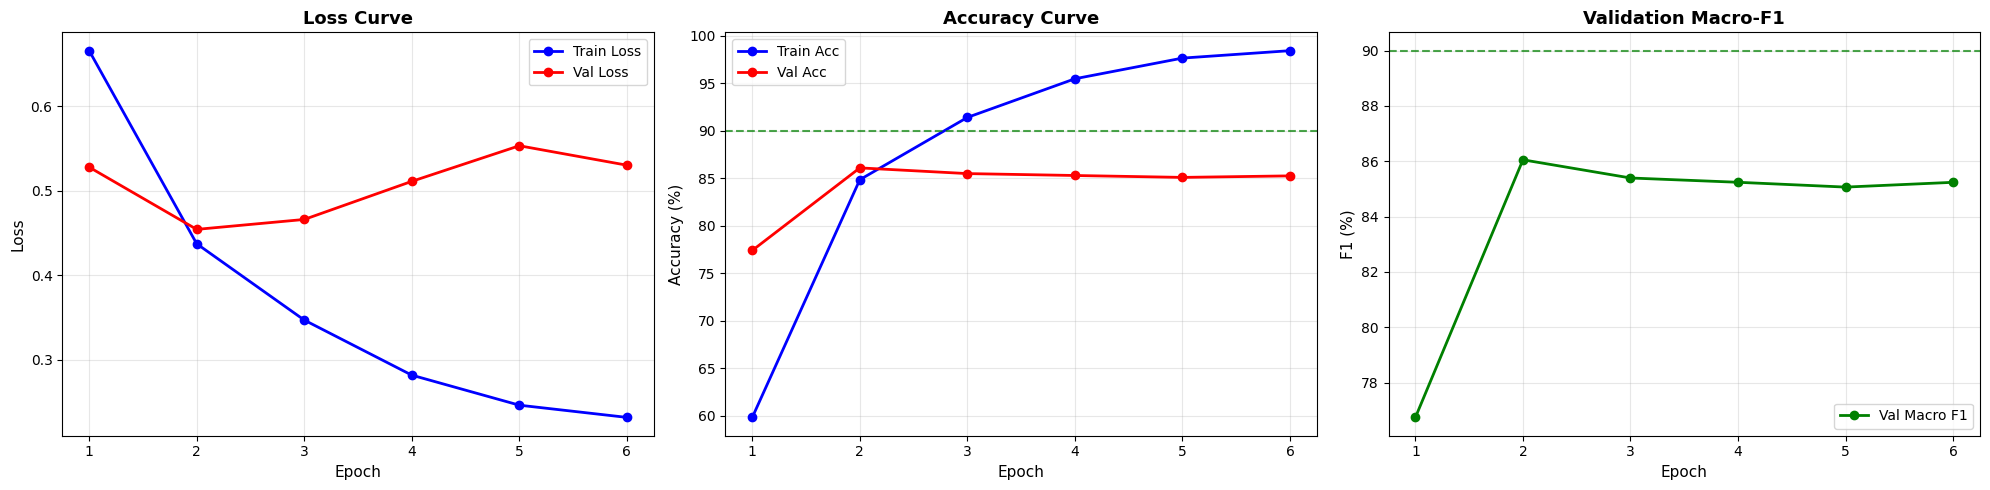


🏆 Best Results:
  Epoch: 2
  Train Acc: 84.84%
  Val Acc: 86.08%
  Val F1: 86.05%
  Val Loss: 0.4542


In [35]:
print()
print("✅ Training completed!")

# Plot training history
plot_training_history(history)


# Print best results
best_epoch = np.argmax(history['val_f1'])
print()
print("🏆 Best Results:")
print(f"  Epoch: {best_epoch + 1}")
print(f"  Train Acc: {history['train_acc'][best_epoch]:.2f}%")
print(f"  Val Acc: {history['val_acc'][best_epoch]:.2f}%")
print(f"  Val F1: {history['val_f1'][best_epoch]:.2f}%")
print(f"  Val Loss: {history['val_loss'][best_epoch]:.4f}")

## Evaluate on Test Set

📊 Evaluating model on IMDB test set...



Evaluating: 100%|██████████| 521/521 [06:15<00:00,  1.39it/s]

Classification Report (Test Set):
              precision    recall  f1-score   support

    Negative     0.8176    0.8927    0.8535     12500
    Positive     0.8819    0.8009    0.8394     12500

    accuracy                         0.8468     25000
   macro avg     0.8497    0.8468    0.8465     25000
weighted avg     0.8497    0.8468    0.8465     25000

Test Accuracy: 84.68%
Test Macro-F1: 84.65%

⚠️  Current accuracy: 84.68%. Target: 90%. Need 5.32% more.


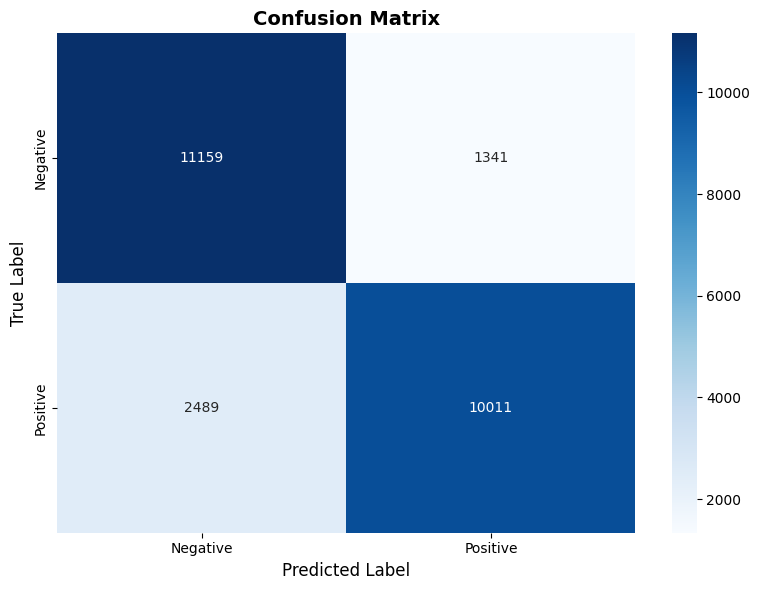

In [36]:
print("📊 Evaluating model on IMDB test set...")
print()

# Load best model
model.load_state_dict(torch.load('best_model.pt', map_location=device))
model.eval()

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc='Evaluating'):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        logits, _ = model(input_ids, attention_mask)
        probs = torch.softmax(logits, dim=1)
        predicted = torch.argmax(probs, dim=1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())


class_names = LABEL_NAMES

print('=' * 60)
print('Classification Report (Test Set):')
print('=' * 60)
print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))


acc = accuracy_score(all_labels, all_preds) * 100
macro_f1 = f1_score(all_labels, all_preds, average='macro') * 100

print(f"Test Accuracy: {acc:.2f}%")
print(f"Test Macro-F1: {macro_f1:.2f}%")

if acc >= 90:
    print("\n🎉 SUCCESS! Target of 90% accuracy achieved!")
else:
    print(f"\n⚠️  Current accuracy: {acc:.2f}%. Target: 90%. Need {90 - acc:.2f}% more.")

plot_confusion_matrix(all_labels, all_preds, class_names)

## Test Predictions

In [37]:
def predict_sentiment(text, model, tokenizer, max_length=256):
    """Predict sentiment for a single text"""
    model.eval()

    tokens, mask = tokenizer.encode(text, max_length=max_length, return_mask=True)
    input_ids = torch.tensor([tokens]).to(device)
    attention_mask = torch.tensor([mask]).to(device)

    with torch.no_grad():
        logits, _ = model(input_ids, attention_mask)
        probs = torch.softmax(logits, dim=1)
        predicted = torch.argmax(probs, dim=1)

    sentiment_map = {0: 'Negative', 1: 'Positive'}

    print('=' * 60)
    print(f"Text: {text}")
    print('=' * 60)
    print(f"Predicted Sentiment: {sentiment_map[predicted.item()]}")
    print(f"Confidence: {probs[0][predicted].item()*100:.2f}%")
    print()
    print('Probability Distribution:')
    print(f"  Negative: {probs[0][0].item()*100:.2f}%")
    print(f"  Positive: {probs[0][1].item()*100:.2f}%")
    print('=' * 60)
    print()

    return predicted.item(), probs[0].cpu().numpy()


# Test examples
test_examples = [
    "This is one of the best movies I have watched in years. Absolutely loved it!",
    "Terrible film. Boring plot and weak acting. Complete waste of time.",
    "Excellent storytelling, strong performances, and great pacing. Highly recommend!",
    "I regret watching this. It was painfully slow and dull. Do not watch.",
    "The movie had its moments but overall was just average.",
    "An absolute masterpiece! Best film of the year by far!",
    "Horrible screenplay and terrible direction. The worst movie I've ever seen.",
    "Not bad, but could have been much better with improved editing."
]

print("🧪 Testing model predictions:")
print()

for text in test_examples:
    predict_sentiment(text, model, tokenizer, max_length=MAX_LENGTH)

🧪 Testing model predictions:

Text: This is one of the best movies I have watched in years. Absolutely loved it!
Predicted Sentiment: Positive
Confidence: 98.66%

Probability Distribution:
  Negative: 1.34%
  Positive: 98.66%

Text: Terrible film. Boring plot and weak acting. Complete waste of time.
Predicted Sentiment: Negative
Confidence: 95.14%

Probability Distribution:
  Negative: 95.14%
  Positive: 4.86%

Text: Excellent storytelling, strong performances, and great pacing. Highly recommend!
Predicted Sentiment: Positive
Confidence: 98.75%

Probability Distribution:
  Negative: 1.25%
  Positive: 98.75%

Text: I regret watching this. It was painfully slow and dull. Do not watch.
Predicted Sentiment: Negative
Confidence: 95.45%

Probability Distribution:
  Negative: 95.45%
  Positive: 4.55%

Text: The movie had its moments but overall was just average.
Predicted Sentiment: Negative
Confidence: 51.54%

Probability Distribution:
  Negative: 51.54%
  Positive: 48.46%

Text: An absolute

## Save Complete Model

In [38]:
# Save everything needed for inference

save_dict = {
    'model_state_dict': model.state_dict(),
    'model_config': MODEL_CONFIG,
    'tokenizer_word2idx': tokenizer.word2idx,
    'tokenizer_idx2word': tokenizer.idx2word,
    'training_history': history,
    'class_names': LABEL_NAMES
}

torch.save(save_dict, 'tinyllm_complete.pt')
print("✅ Complete model saved as 'tinyllm_complete.pt'")

# Save model architecture summary
with open('model_summary.txt', 'w') as f:
    f.write("Enhanced TinyLLM Model Summary\n")
    f.write("=" * 60 + "\n\n")
    f.write(f"Total Parameters: {total_params:,}\n")
    f.write(f"Model Size: ~{total_params * 4 / (1024**2):.2f} MB\n\n")
    f.write("Configuration:\n")
    for key, value in MODEL_CONFIG.items():
        f.write(f"  {key}: {value}\n")
    f.write(f"\nBest Validation Accuracy: {max(history['val_acc']):.2f}%\n")
    f.write(f"Best Validation F1: {max(history['val_f1']):.2f}%\n")
    f.write(f"Test Accuracy: {acc:.2f}%\n")
    f.write(f"Test F1: {macro_f1:.2f}%\n")

print("✅ Model summary saved as 'model_summary.txt'")

✅ Complete model saved as 'tinyllm_complete.pt'
✅ Model summary saved as 'model_summary.txt'


## Load and Test Saved Model

In [39]:
# Example: How to load and use the saved model later


def load_model(filepath='tinyllm_complete.pt'):
    """Load saved model for inference"""

    checkpoint = torch.load(filepath, map_location=device)

    tokenizer = AdvancedTokenizer()
    tokenizer.word2idx = checkpoint['tokenizer_word2idx']
    tokenizer.idx2word = checkpoint['tokenizer_idx2word']

    model = TinyLLM(**checkpoint['model_config'])
    model.load_state_dict(checkpoint['model_state_dict'])
    model = model.to(device)
    model.eval()

    return model, tokenizer, checkpoint


# Load model
print("Loading saved model...")
loaded_model, loaded_tokenizer, checkpoint = load_model()
print("✅ Model loaded successfully!")


# Test with loaded model
test_text = "This product was amazing! Highly recommend to everyone."
predict_sentiment(test_text, loaded_model, loaded_tokenizer, max_length=checkpoint['model_config']['max_len'])

Loading saved model...
✅ Model loaded successfully!
Text: This product was amazing! Highly recommend to everyone.
Predicted Sentiment: Positive
Confidence: 98.66%

Probability Distribution:
  Negative: 1.34%
  Positive: 98.66%



(1, array([0.01343695, 0.98656297], dtype=float32))

## Model Performance Analysis

In [40]:
# Analyze model performance

print("📈 Model Performance Analysis")
print()
print("="*60)


print()
print("1. Training Summary:")
print(f"   Total Epochs: {len(history['train_loss'])}")
print(f"   Final Train Accuracy: {history['train_acc'][-1]:.2f}%")
print(f"   Final Val Accuracy: {history['val_acc'][-1]:.2f}%")
print(f"   Best Val Accuracy: {max(history['val_acc']):.2f}%")
print(f"   Best Val Macro-F1: {max(history['val_f1']):.2f}%")
print(f"   Best Epoch: {np.argmax(history['val_f1']) + 1}")


print()
print("2. Test Set Performance:")
print(f"   Test Accuracy: {acc:.2f}%")
print(f"   Test Macro-F1: {macro_f1:.2f}%")


print()
print("3. Model Size:")
print(f"   Parameters: {total_params:,}")
print(f"   Size: ~{total_params * 4 / (1024**2):.2f} MB")


print()
print("4. Architecture:")
print(f"   Embedding Dim: {MODEL_CONFIG['d_model']}")
print(f"   Num Layers: {MODEL_CONFIG['num_layers']}")
print(f"   Num Heads: {MODEL_CONFIG['num_heads']}")
print(f"   Vocabulary Size: {MODEL_CONFIG['vocab_size']}")
print(f"   Max Sequence Length: {MODEL_CONFIG['max_len']}")


print()
print("="*60)

if acc >= 90:
    print("\n🎉 TARGET ACHIEVED! 90%+ accuracy on test set!")
else:
    print(f"\n📊 Current: {acc:.2f}% | Target: 90%")
    print("\n💡 Tips to improve further:")
    print("   - Train for more epochs")
    print("   - Try larger model (d_model=512)")
    print("   - Use pre-trained embeddings (GloVe, Word2Vec)")
    print("   - Ensemble multiple models")

📈 Model Performance Analysis


1. Training Summary:
   Total Epochs: 6
   Final Train Accuracy: 98.41%
   Final Val Accuracy: 85.24%
   Best Val Accuracy: 86.08%
   Best Val Macro-F1: 86.05%
   Best Epoch: 2

2. Test Set Performance:
   Test Accuracy: 84.68%
   Test Macro-F1: 84.65%

3. Model Size:
   Parameters: 17,885,570
   Size: ~68.23 MB

4. Architecture:
   Embedding Dim: 384
   Num Layers: 6
   Num Heads: 8
   Vocabulary Size: 15000
   Max Sequence Length: 256


📊 Current: 84.68% | Target: 90%

💡 Tips to improve further:
   - Train for more epochs
   - Try larger model (d_model=512)
   - Use pre-trained embeddings (GloVe, Word2Vec)
   - Ensemble multiple models
